In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("../shared").resolve()))
from constants import (
    CAPTIONS_PATH,
    CONTROLLER_COLOURS,
    CVA_EM_4_PATH,
    ERA_EM_4_PATH,
    ERA_PATH,
    FIGURES_PATH,
    N_BURNIN,
    N_FFT,
    RANDOM_SEED,
)
from pgf_utils import apply_figure_style, configure_pgf, configure_screen, figure_inches, save_pgf
from system_estimate import SystemEstimate

from spectral_control import (
    NOTEBOOK_GITHUB_URL,
    LQGController,
    LQIController,
    MPCController,
    NoInputController,
    SpectralTarget,
    SystemModel,
    make_spectral_control_figure,
    random_search,
    run_closed_loop,
    spectral_metrics,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
# Swap ESTIMATOR_PATH to ERA_PATH or CVA_EM_4_PATH to compare estimators.
ESTIMATOR_PATH = ERA_EM_4_PATH

T_SIM     = 400    # total closed-loop steps (~4 periods of f=0.01)
T_OPT     = 200    # steps used during hyperparameter search
N_TRIALS  = 8      # random-search trials per controller
OPT_SEED  = 1      # RNG seed for hyperparameter search

# Target spectrum.  OFFSET is the desired physical population mean; controllers
# subtract model.base_mean internally to obtain the centred deviation.
# With baseline ~0.24 and max reachable ~5.4, OFFSET=2.5 gives a centred
# target of ~2.3, well within the feasible range.
OFFSET = 4
TARGET_COMPONENTS = [
    (0.01, 1.5, 0.0),  # (freq, amplitude, phase) — period 100 steps
    (0.03, 1.5, 0.0),  # period 33 steps
]

# lambda_var=1.0 uses the full per-neuron cost C^T C instead of the population-
# mean-only cost cmean ⊗ cmean, driving all 16 neurons to track the target.
LAMBDA_VAR = 1.0

MPC_HORIZON = 30   # >= one period of f=0.03

# Colours for each controller (imported from constants — distinct from estimator colours)
COLOURS = CONTROLLER_COLOURS

# Hyperparameter search spaces (log-uniform)
PARAM_SPACES = {
    "LQG": {"q_track": (1.0, 200.0), "r_effort": (10.0, 2000.0)},
    "LQI": {"q_track": (1.0, 200.0), "r_effort": (10.0, 2000.0), "q_int": (0.001, 0.1)},
    "MPC": {"q_track": (1.0, 200.0), "r_u":     (1.0,  100.0),  "r_du":  (1.0, 100.0)},
}

In [3]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
est = SystemEstimate.load(ESTIMATOR_PATH)
model = SystemModel.from_estimate(est, y_mean=np.zeros(16))
target = SpectralTarget(TARGET_COMPONENTS, offset=OFFSET)

def brain_factory(s: int = RANDOM_SEED) -> Brain:
    return Brain(random_seed=s)

# Controller factories (lambda_var injected; hyperparams filled by search)
MAKE_CTRL = {
    "LQG": lambda p: LQGController(model, lambda_var=LAMBDA_VAR, **p),
    "LQI": lambda p: LQIController(model, lambda_var=LAMBDA_VAR, **p),
    "MPC": lambda p: MPCController(model, horizon=MPC_HORIZON, lambda_var=LAMBDA_VAR, **p),
}

print(f"Estimator : {est.label}  (n_x = {model.n_x})")
print(f"Target offset (physical): {OFFSET}")
print(f"Target freqs: {[c[0] for c in TARGET_COMPONENTS]}, amps: {[c[1] for c in TARGET_COMPONENTS]}")
# Expected SNR in population mean (rough: amp * |H(f)| / noise_std_of_mean)
R_diag_mean = np.diag(est.R).mean()
noise_mean_std = np.sqrt(R_diag_mean / 16)
for f, A, _ in TARGET_COMPONENTS:
    z = np.exp(2j * np.pi * f)
    H = model.cmean @ np.linalg.solve(z * np.eye(model.n_x) - model.A, model.B)
    snr = A * abs(H[0]) / noise_mean_std
    print(f"  f={f}: |H0|={abs(H[0]):.2f}, expected SNR ~{snr:.1f}")

Estimator : ERA+EM $n_x=4$  (n_x = 4)
Target offset (physical): 4
Target freqs: [0.01, 0.03], amps: [1.5, 1.5]
  f=0.01: |H0|=7.88, expected SNR ~50.5
  f=0.03: |H0|=2.96, expected SNR ~18.9


In [4]:
# ── 4. Hyperparameter search ──────────────────────────────────────────────────
best_params = {}
with tqdm(total=N_TRIALS * len(PARAM_SPACES), desc="Searching", unit="run") as pbar:
    for name, space in PARAM_SPACES.items():
        params, err = random_search(
            brain_factory=lambda: brain_factory(),
            model=model,
            target=target,
            make_ctrl=MAKE_CTRL[name],
            param_space=space,
            n_trials=N_TRIALS,
            T_opt=T_OPT,
            warmup=T_OPT // 4,
            seed=OPT_SEED,
            n_burnin=N_BURNIN,
        )
        best_params[name] = params
        pbar.update(N_TRIALS)
        print(f"{name}: best RMS={err:.4f}  params={params}")

Searching:   0%|          | 0/24 [00:00<?, ?run/s]

LQG: best RMS=1.1332  params={'q_track': 18.39211021406778, 'r_effort': 11.572157775836274}
LQI: best RMS=1.0691  params={'q_track': 2.938709193146158, 'r_effort': 40.141247440775665, 'q_int': 0.031675927863265146}
MPC: best RMS=1.7308  params={'q_track': 11.053816395879764, 'r_u': 1.8538875781431292, 'r_du': 6.400677900893796}


In [5]:
# ── 5. Simulation ─────────────────────────────────────────────────────────────
controllers = {name: MAKE_CTRL[name](best_params[name]) for name in PARAM_SPACES}
results = {}

with tqdm(total=1 + len(controllers), desc="Simulating", unit="run") as pbar:
    pbar.set_postfix(controller="uncontrolled")
    result_unc = run_closed_loop(
        brain_factory=lambda: brain_factory(),
        model=model,
        controller=NoInputController(model.n_u),
        target=target,
        T=T_SIM,
        n_burnin=N_BURNIN,
    )
    pbar.update(1)

    for name, ctrl in controllers.items():
        pbar.set_postfix(controller=name)
        results[name] = run_closed_loop(
            brain_factory=lambda: brain_factory(),
            model=model,
            controller=ctrl,
            target=target,
            T=T_SIM,
            n_burnin=N_BURNIN,
        )
        pbar.update(1)

metrics = spectral_metrics(results, target, n_fft=N_FFT)
print("\nSpectral metrics:")
print(metrics.to_string())

Simulating:   0%|          | 0/4 [00:00<?, ?run/s]


Spectral metrics:
            spectral_rms_error  spectral_max_error  off_target_power
controller                                                          
LQG                     0.6154              0.7138            0.0331
LQI                     0.5761              0.7484            0.0334
MPC                     0.9828              1.2325            0.0322


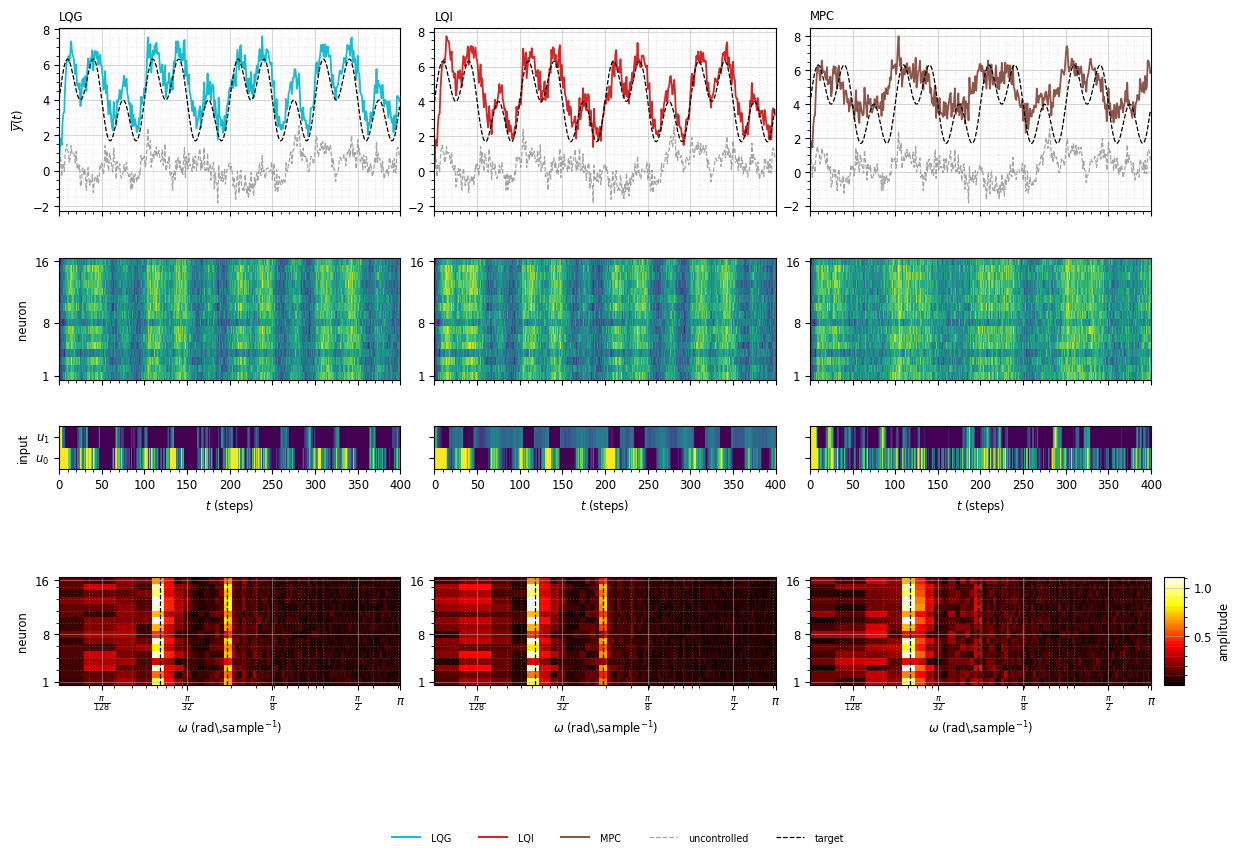

In [6]:
# ── 6. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_spectral_control_figure(
    results,
    result_unc=result_unc,
    target=target,
    model=model,
    controller_colours=COLOURS,
    figsize=(13, 9),
    n_fft=N_FFT,
)
apply_figure_style(fig)
plt.show()

In [7]:
# ── 7. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0
FIG_HEIGHT_FRAC = 0.4

configure_pgf()
fig = make_spectral_control_figure(
    results,
    result_unc=result_unc,
    target=target,
    model=model,
    controller_colours=COLOURS,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
    n_fft=N_FFT,
)
save_pgf(fig, FIGURES_PATH / "spectral_control.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/spectral_control.pgf


In [8]:
# ── 8. Caption ────────────────────────────────────────────────────────────────
from pgf_utils import save_caption

freq_str = ", ".join(f"{c[0]:.2f}" for c in TARGET_COMPONENTS)
amp_str  = ", ".join(f"{c[1]:.2f}" for c in TARGET_COMPONENTS)

caption = (
    f"Closed-loop spectral control using the {est.label} model ($n_x = {model.n_x}$), "
    f"controller hyperparameters tuned by random search ({N_TRIALS} trials each). "
    f"The target is a sum of two sinusoids at $f \\in \\{{{freq_str}\\}}$ cycles per sample "
    f"with amplitudes $A \\in \\{{{amp_str}\\}}$, centred on a physical mean of {OFFSET}. "
    "Each column shows one controller (LQG, LQI, MPC) with a per-neuron tracking cost "
    f"($\\lambda_{{\\mathrm{{var}}}} = {LAMBDA_VAR:.0f}$). "
    "Row 1: physical population mean $\\overline{y}(t)$, uncontrolled baseline (grey dashed), "
    "and target reference (black dashed). "
    "Row 2: per-neuron observations $y(t)$ as a neuron $\\times$ time heatmap. "
    "Row 3: applied inputs $u(t)$. "
    "Row 4: per-neuron amplitude spectral density (neuron $\\times$ angular frequency $\\omega$, "
    "log scale); target frequencies shown as red dashed lines."
)

save_caption(CAPTIONS_PATH / "spectral_control.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/spectral_control.tex
Closed-loop spectral control using the ERA+EM $n_x=4$ model ($n_x = 4$), controller hyperparameters tuned by random search (8 trials each). The target is a sum of two sinusoids at $f \in \{0.01, 0.03\}$ cycles per sample with amplitudes $A \in \{1.50, 1.50\}$, centred on a physical mean of 4. Each column shows one controller (LQG, LQI, MPC) with a per-neuron tracking cost ($\lambda_{\mathrm{var}} = 1$). Row 1: physical population mean $\overline{y}(t)$, uncontrolled baseline (grey dashed), and target reference (black dashed). Row 2: per-neuron observations $y(t)$ as a neuron $\times$ time heatmap. Row 3: applied inputs $u(t)$. Row 4: per-neuron amplitude spectral density (neuron $\times$ angular frequency $\omega$, log scale); target frequencies shown as red dashed lines.
